In [1]:
from Distance import manhattan_distance
import matplotlib.pyplot as plt
from src.FungiClustering import FungiInspiredClustering
from sklearn.metrics import silhouette_score
import pandas as pd

In [8]:
df=pd.read_csv(r'../src/Pruebas/CleanDataset.csv')

In [9]:
df

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,0.000000,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,0.500000,6
8946,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,0.000000,6
8947,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,0.250000,6
8948,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,0.250000,6


Coeficiente de Silhouette: 0.4743114981179011

Centroides finales:
[[ 5.27304350e+03  2.20513008e+00  1.40453785e+03  6.74713449e+02
   7.32462387e+02  1.08730057e+04 -1.53726715e+00 -3.46485932e-01
  -4.21714770e-01 -7.09788443e-01  2.13116554e+01  2.07949450e+01
   1.06805252e+04  1.45570158e+04 -1.45979222e+00  1.22921403e+01]
 [ 4.81916034e+03  2.17998678e+00  6.65400639e+02  4.06003985e+02
   2.60246368e+02  3.17937713e+03 -1.11371448e+00 -1.05452734e+00
   1.06329266e+00  8.82566845e-01  9.81164345e+00  1.03372245e+01
   8.96642971e+03  2.53440684e+03  2.15265013e-01  1.35300453e+01]
 [ 8.65303976e+02  1.73606156e+00  6.07227321e+02  3.05910642e+02
   3.00456261e+02  4.87493196e+02 -1.43433232e+00 -1.18443092e+00
   1.88115656e+00 -1.43063610e+00  2.30292258e+00  1.25450800e+01
   3.26552381e+03  1.01734882e+03  7.62534860e-02  1.26695270e+01]
 [ 2.60457774e+03  7.69271073e-01  5.54172201e+03  3.67344639e+03
   1.87245828e+03  4.37578708e+02 -1.14973385e-01  4.89467521e-01
   1.0

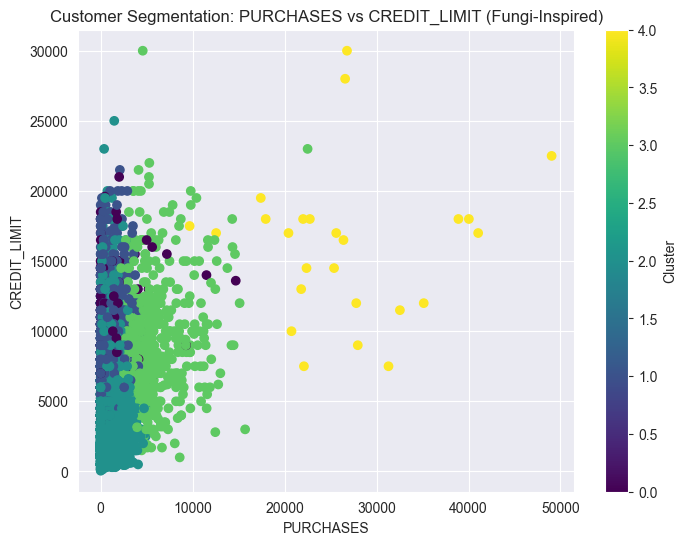

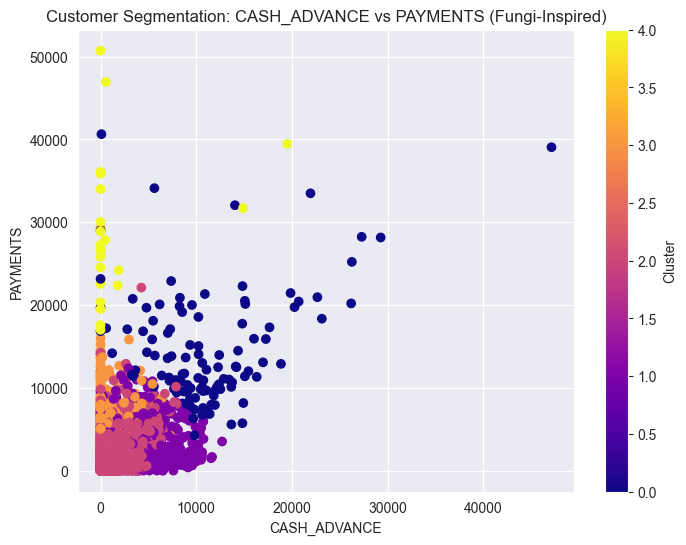

In [10]:
n_clusters = 5
fungi_clustering = FungiInspiredClustering(manhattan_distance,n_clusters=n_clusters, max_iter=100, local_radius=0.5, global_radius=2.0)
fungi_clustering.fit(df.to_numpy())

# Asignar las etiquetas de clúster al dataframe
df['Cluster'] = fungi_clustering.labels

# Métricas de rendimiento
silhouette_avg = silhouette_score(df.to_numpy(), df['Cluster'])
print(f"Coeficiente de Silhouette: {silhouette_avg}")

# Imprimir datos de centroides y asignaciones
print(f"\nCentroides finales:\n{fungi_clustering.centroids}\n")

# Tamaño de cada clúster
cluster_sizes = df['Cluster'].value_counts().sort_index()
print(f"Tamaño de cada clúster:\n{cluster_sizes}\n")

# Visualización: Graficar PURCHASES vs CREDIT_LIMIT con los clústeres
plt.figure(figsize=(8,6))
plt.scatter(df['PURCHASES'], df['CREDIT_LIMIT'], c=df['Cluster'], cmap='viridis', marker='o')
plt.title("Customer Segmentation: PURCHASES vs CREDIT_LIMIT (Fungi-Inspired)")
plt.xlabel("PURCHASES")
plt.ylabel("CREDIT_LIMIT")
plt.colorbar(label="Cluster")
plt.show()

# Visualización: CASH_ADVANCE vs PAYMENTS
plt.figure(figsize=(8,6))
plt.scatter(df['CASH_ADVANCE'], df['PAYMENTS'], c=df['Cluster'], cmap='plasma', marker='o')
plt.title("Customer Segmentation: CASH_ADVANCE vs PAYMENTS (Fungi-Inspired)")
plt.xlabel("CASH_ADVANCE")
plt.ylabel("PAYMENTS")
plt.colorbar(label="Cluster")
plt.show()